# Trabalho 05-2 — Manipulação PBM/PGM
## Binarização por limiar e negativo, com saída em PBM P1

**Disciplina:** Computação Gráfica / Processamento de Imagens Digitais
**Professor:** André Alessandro Stein
**Aluno:** Igor
**Instituição:** IFC — Campus Rio do Sul

### Enunciado

> Sobre o arquivo de imagem `Entrada.pgm` (8 bits em escala de cinza, 0–255),
> gerar arquivo de saída binário, tipo **PBM – P1 (ASCII)**, ou seja, com duas
> tonalidades (preto ou branco):
>
> **a)** Ajustar valor do limiar em 128; se `valorpixel <= limiar := 0` e
> `valor > limiar := 1`.
>
> **b)** Definir limiar (fator de ajuste), seguindo a mesma regra.
>
> **c)** Aplicar negativo sobre a imagem gerada no item "a". Manter formato P1.

### Plano de trabalho

1. Ler o PGM de entrada e caracterizá-lo.
2. Implementar escritor PBM P1 com validação.
3. **(a)** Binarizar com limiar fixo 128.
4. **(b)** Parametrizar o limiar, varrer valores e determinar um limiar
   automático pelo método de Otsu.
5. **(c)** Aplicar o negativo sobre o resultado do item (a).

### Referências

- STEIN, A. A.; HECK, C. *Processamento de Imagens Digitais* — slides da disciplina.
- LOPES, J. M. Brisson. *Formatos de Imagem*. DEI — IST, Lisboa, 2003 (reed. 2013).

## 1. Fundamentação

### O formato PBM P1

O PBM (*Portable BitMap*) é o membro mais simples da família: imagens a preto e
branco, **sem tons de cinzento**. Cada píxel carrega um único bit. Na variante
ASCII o magic number é `P1`; na binária, `P4`.

Diferença estrutural importante em relação ao PGM e ao PPM: o cabeçalho do P1
**não tem campo `maxval`**. Ele é implícito, sempre 1. A estrutura fica:

1. Magic number `P1`
2. Largura, em píxeis
3. Altura, em píxeis
4. Os `largura × altura` valores, cada um 0 ou 1

Valem as mesmas regras das demais variantes ASCII: comentários com `#` em
qualquer posição, e limite de **70 caracteres por linha**.

### Atenção: conflito de convenção de cor

Há uma divergência que precisa ser registrada, porque afeta como o arquivo
gerado será exibido.

| Fonte | Convenção |
|-------|-----------|
| Especificação oficial do PBM | `1` = **preto**, `0` = **branco** |
| Apostila da disciplina (fig. 2.1) | `1` = **branco**, `0` = **preto** |

Na figura 2.1 da apostila, o exemplo `feep.pbm` exibe as letras "FEEP" em branco
sobre fundo preto — e são exatamente os valores `1` que traçam as letras. A
apostila portanto adota a convenção inversa à do padrão.

O enunciado determina `valor > limiar := 1`, isto é, píxeis **claros** viram `1`.
Isso só produz uma binarização visualmente coerente sob a convenção da apostila.

**Decisão adotada:** sigo o enunciado literalmente na geração do arquivo — píxeis
acima do limiar recebem `1`. Nas visualizações, exibo o resultado sob as **duas**
convenções, para deixar o efeito explícito e permitir conferir qual delas o
visualizador de destino aplica.

### Binarização por limiar

A binarização (*thresholding*) é outra transformação pontual, do tipo degrau:

    g(x, y) = 0, se f(x, y) <= limiar
              1, se f(x, y) >  limiar

É a redução de profundidade mais extrema possível: de 256 níveis para 2, ou seja,
de 8 bits para 1 bit. A perda de informação é massiva e irreversível — toda a
gradação tonal desaparece, restando apenas a informação de forma e contorno.

É justamente por isso que a binarização é um passo comum de **pré-processamento**
em visão computacional: descartar a gradação é desejável quando o objetivo é
segmentar objetos, reconhecer caracteres ou detectar contornos.

In [1]:
# Bibliotecas e configuração

import textwrap
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

BASE = Path.cwd()
ENTRADA = BASE / "entrada"
SAIDA = BASE / "saida"
SAIDA.mkdir(exist_ok=True)

ARQUIVO_ENTRADA = ENTRADA / "Entrada.pgm"

LIMITE_COLUNA = 70      # limite das variantes ASCII (spec PBM)
LIMIAR_FIXO = 128       # item (a)

print(f"Entrada existe : {ARQUIVO_ENTRADA.exists()}")
print(f"Caminho        : {ARQUIVO_ENTRADA}")
print(f"Limiar item (a): {LIMIAR_FIXO}")

Entrada existe : True
Caminho        : /home/igorkg/PycharmProjects/TrabalhoRGBProcessamentoDigitalDeImagem/TrabalhoBinarização/entrada/Entrada.pgm
Limiar item (a): 128


In [2]:
# --- Leitor PGM P2 (reaproveitado das atividades anteriores) ---

def _fluxo_tokens(arquivo):
    """Gera tokens do arquivo, descartando comentários iniciados por '#'."""
    for linha in arquivo:
        util = linha.split("#", 1)[0]
        for token in util.split():
            yield token


def ler_pgm_p2(caminho):
    """Lê um arquivo PGM tipo P2 e devolve (matriz 2D, maxval)."""
    with open(caminho, "r", encoding="ascii") as f:
        it = _fluxo_tokens(f)

        magic = next(it)
        if magic != "P2":
            raise ValueError(f"Magic number inesperado: {magic!r} (esperado 'P2')")

        largura, altura, maxval = (int(next(it)) for _ in range(3))
        dados = np.fromiter(map(int, it), dtype=np.int32, count=largura * altura)

    return dados.reshape(altura, largura), maxval

In [3]:
# --- Leitor e escritor PBM P1 ---

def escrever_pbm_p1(caminho, imagem, comentario=None, limite_coluna=LIMITE_COLUNA):
    """
    Grava uma matriz 2D de 0s e 1s como arquivo PBM tipo P1 (ASCII).

    O P1 não possui campo maxval — ele é implícito e sempre igual a 1.
    Comentários longos são quebrados em várias linhas '#', pois o limite de
    70 caracteres vale para todas as linhas do arquivo.
    """
    imagem = np.asarray(imagem)

    if imagem.ndim != 2:
        raise ValueError(f"Esperada matriz 2D, recebido shape {imagem.shape}")

    valores = set(np.unique(imagem).tolist())
    if not valores.issubset({0, 1}):
        raise ValueError(f"PBM aceita apenas 0 e 1, encontrado: {sorted(valores)}")

    altura, largura = imagem.shape

    # Tokens de 1 caractere + 1 separador -> cabem (70+1)//2 = 35 por linha
    n = (limite_coluna + 1) // 2
    plano = imagem.reshape(-1).tolist()

    with open(caminho, "w", encoding="ascii", newline="\n") as f:
        f.write("P1\n")

        if comentario:
            for trecho in textwrap.wrap(comentario, width=limite_coluna - 2):
                f.write(f"# {trecho}\n")

        f.write(f"{largura} {altura}\n")      # sem maxval

        linhas = [" ".join(map(str, plano[i:i + n]))
                  for i in range(0, len(plano), n)]
        f.write("\n".join(linhas))
        f.write("\n")

    return caminho


def ler_pbm_p1(caminho):
    """Lê um arquivo PBM tipo P1 e devolve a matriz 2D de 0s e 1s."""
    with open(caminho, "r", encoding="ascii") as f:
        it = _fluxo_tokens(f)

        magic = next(it)
        if magic != "P1":
            raise ValueError(f"Magic number inesperado: {magic!r} (esperado 'P1')")

        largura, altura = (int(next(it)) for _ in range(2))   # sem maxval
        dados = np.fromiter(map(int, it), dtype=np.int32, count=largura * altura)

    return dados.reshape(altura, largura)


def verificar_limite_colunas(caminho, limite=LIMITE_COLUNA):
    maior = 0
    with open(caminho, "r", encoding="ascii") as f:
        for numero, linha in enumerate(f, start=1):
            comprimento = len(linha.rstrip("\n"))
            if comprimento > limite:
                raise AssertionError(f"Linha {numero}: {comprimento} caracteres")
            maior = max(maior, comprimento)
    return maior


print(f"Valores por linha no P1: {(LIMITE_COLUNA + 1) // 2}")

Valores por linha no P1: 35


IMAGEM DE ENTRADA
----------------------------------------------
Dimensões        : 800 x 800
Total de píxeis  : 640,000
maxval           : 255
Mínimo / Máximo  : 13 / 243
Média            : 115.93
Mediana          : 118
Desvio padrão    : 53.01
Níveis distintos : 231 de 256


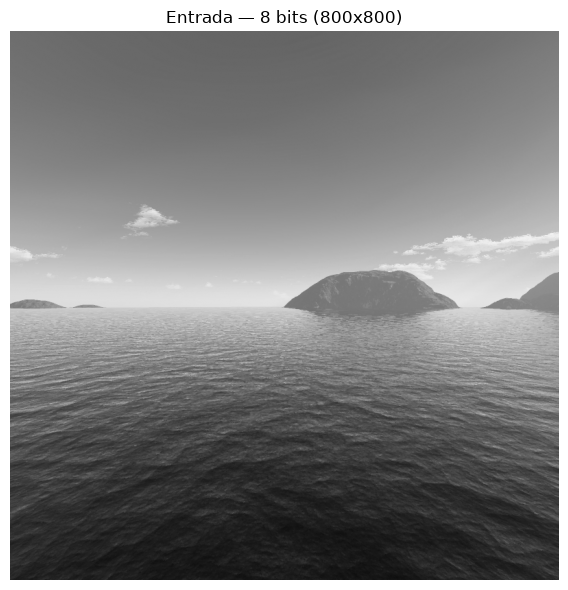

In [4]:
# --- Leitura e caracterização da entrada ---

original, maxval = ler_pgm_p2(ARQUIVO_ENTRADA)
altura, largura = original.shape

print("IMAGEM DE ENTRADA")
print("-" * 46)
print(f"Dimensões        : {largura} x {altura}")
print(f"Total de píxeis  : {original.size:,}")
print(f"maxval           : {maxval}")
print(f"Mínimo / Máximo  : {original.min()} / {original.max()}")
print(f"Média            : {original.mean():.2f}")
print(f"Mediana          : {int(np.median(original))}")
print(f"Desvio padrão    : {original.std():.2f}")
print(f"Níveis distintos : {np.unique(original).size} de {maxval + 1}")


def exibir_cinza(imagem, maxval, titulo, tamanho=5):
    plt.figure(figsize=(tamanho, tamanho))
    plt.imshow(imagem, cmap="gray", vmin=0, vmax=maxval)
    plt.title(titulo)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


exibir_cinza(original, maxval, f"Entrada — 8 bits ({largura}x{altura})", tamanho=6)

---

## Item (a) — Limiar fixo em 128

Regra do enunciado:

    valorpixel <= 128  ->  0
    valorpixel >  128  ->  1

O valor 128 é o ponto médio da escala de 8 bits. É um limiar **arbitrário**: não
leva em conta nada sobre o conteúdo da imagem, apenas divide a faixa teórica ao
meio. Serve como referência, e o item (b) explora alternativas melhores.

Observação sobre o operador: o enunciado usa `<=` para o preto, o que significa
que o próprio valor 128 é classificado como 0. Isso importa — trocar `<=` por `<`
moveria todos os píxeis de valor exatamente 128 para a outra classe.

In [5]:
# --- Item (a): binarização com limiar 128 ---

def binarizar(imagem, limiar):
    """
    Binariza pela regra do enunciado: <= limiar vira 0, > limiar vira 1.

    O operador '>' do NumPy produz exatamente essa semântica, o que evita
    escrever a comparação de forma que possa inverter acidentalmente o
    tratamento do valor de fronteira.
    """
    return (imagem > limiar).astype(np.int32)


item_a = binarizar(original, LIMIAR_FIXO)

n_uns = int(item_a.sum())
n_zeros = item_a.size - n_uns

print(f"Limiar aplicado : {LIMIAR_FIXO}")
print("-" * 46)
print(f"Píxeis = 0 (<= {LIMIAR_FIXO}) : {n_zeros:>9,}  ({n_zeros / item_a.size * 100:5.2f}%)")
print(f"Píxeis = 1 (>  {LIMIAR_FIXO}) : {n_uns:>9,}  ({n_uns / item_a.size * 100:5.2f}%)")
print()
print(f"Valores distintos na saída: {sorted(np.unique(item_a).tolist())}")
print(f"Redução de profundidade   : 8 bits -> 1 bit (256 níveis -> 2)")

Limiar aplicado : 128
----------------------------------------------
Píxeis = 0 (<= 128) :   384,870  (60.14%)
Píxeis = 1 (>  128) :   255,130  (39.86%)

Valores distintos na saída: [0, 1]
Redução de profundidade   : 8 bits -> 1 bit (256 níveis -> 2)


In [6]:
# --- Item (a): gravação e validação ---

ARQUIVO_A = SAIDA / "a_binarizada_limiar128.pbm"

escrever_pbm_p1(
    ARQUIVO_A, item_a,
    comentario=f"item (a) - binarizacao por limiar fixo {LIMIAR_FIXO} - "
               f"origem {ARQUIVO_ENTRADA.name}"
)

lida_a = ler_pbm_p1(ARQUIVO_A)
assert np.array_equal(lida_a, item_a), "Round-trip falhou!"

print(f"Arquivo gravado : {ARQUIVO_A.name}")
print(f"Round-trip      : OK")
print(f"Maior linha     : {verificar_limite_colunas(ARQUIVO_A)} caracteres")
print(f"Tamanho         : {ARQUIVO_A.stat().st_size / 1024**2:.2f} MB")
print()
print("Primeiras linhas do arquivo:")
print("-" * 50)
with open(ARQUIVO_A) as f:
    for _ in range(6):
        print(f.readline().rstrip())

Arquivo gravado : a_binarizada_limiar128.pbm
Round-trip      : OK
Maior linha     : 69 caracteres
Tamanho         : 1.22 MB

Primeiras linhas do arquivo:
--------------------------------------------------
P1
# item (a) - binarizacao por limiar fixo 128 - origem Entrada.pgm
800 800
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0


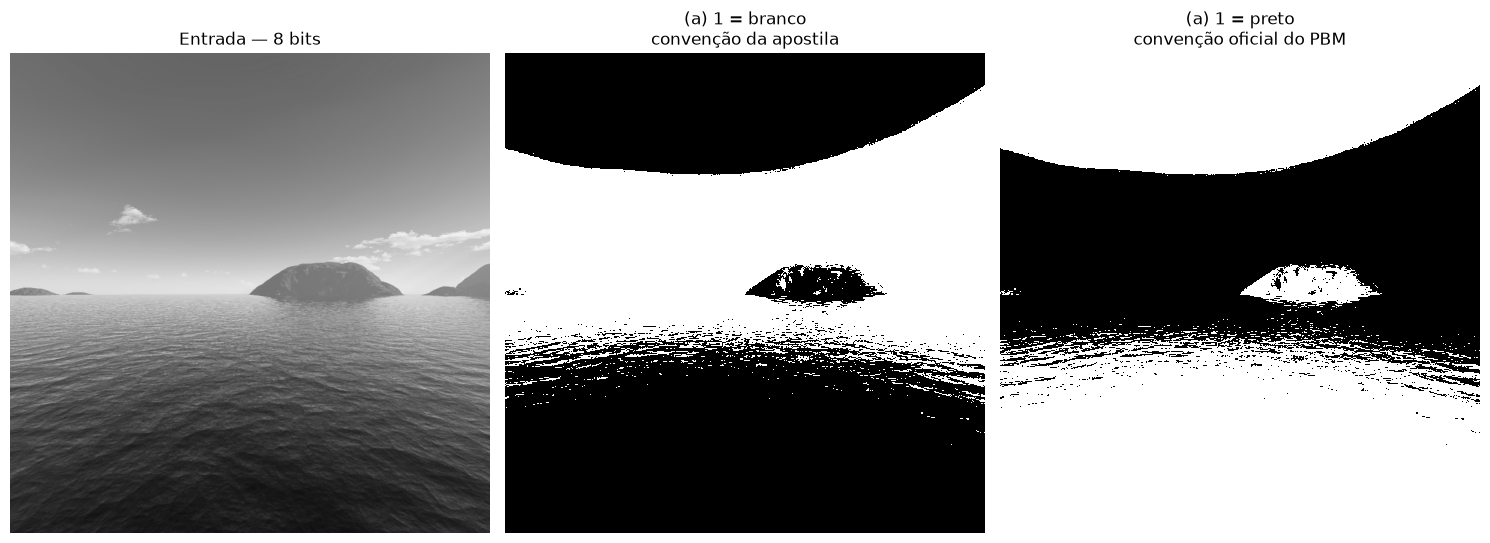

O arquivo gravado é o mesmo nos dois painéis — muda apenas como o
visualizador interpreta os bits. O painel do meio corresponde à
convenção adotada pela apostila e é o resultado visualmente esperado
pela regra do enunciado (píxeis claros -> 1).


In [7]:
# --- Item (a): visualização sob as duas convenções ---

def exibir_pbm(ax, binaria, titulo, um_e_branco=True):
    """
    Exibe uma imagem PBM.

    um_e_branco=True  -> convenção da apostila (1 = branco)
    um_e_branco=False -> convenção oficial do formato (1 = preto)
    """
    dados = binaria if um_e_branco else 1 - binaria
    ax.imshow(dados, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(titulo)
    ax.axis("off")


fig, eixos = plt.subplots(1, 3, figsize=(15, 5.5))

eixos[0].imshow(original, cmap="gray", vmin=0, vmax=maxval)
eixos[0].set_title("Entrada — 8 bits")
eixos[0].axis("off")

exibir_pbm(eixos[1], item_a,
           "(a) 1 = branco\nconvenção da apostila", um_e_branco=True)
exibir_pbm(eixos[2], item_a,
           "(a) 1 = preto\nconvenção oficial do PBM", um_e_branco=False)

plt.tight_layout()
plt.show()

print("O arquivo gravado é o mesmo nos dois painéis — muda apenas como o")
print("visualizador interpreta os bits. O painel do meio corresponde à")
print("convenção adotada pela apostila e é o resultado visualmente esperado")
print("pela regra do enunciado (píxeis claros -> 1).")

---

## Item (b) — Limiar parametrizado

O item pede que o limiar seja um **fator de ajuste**, não um valor fixo. A função
`binarizar` já foi escrita com o limiar como parâmetro, então a implementação
está pronta — o que falta é a parte interessante: **como escolher um bom valor**.

O limiar 128 do item (a) ignora completamente o conteúdo da imagem. Existem
critérios melhores, e três estratégias merecem comparação:

| Critério | Justificativa |
|----------|---------------|
| **Ponto médio da escala** (128) | Arbitrário; ignora a imagem |
| **Média dos píxeis** | Adapta-se ao brilho geral da imagem |
| **Mediana dos píxeis** | Divide a imagem em duas metades de área igual |
| **Otsu** | Maximiza a separação estatística entre as duas classes |

### O método de Otsu

Otsu determina o limiar automaticamente buscando aquele que **maximiza a
variância entre classes** — equivalentemente, que minimiza a variância dentro de
cada classe. A intuição: o melhor limiar é o que produz dois grupos
internamente mais homogêneos e mais distintos entre si.

Para cada limiar candidato `t`, com `ω₀(t)` e `ω₁(t)` as proporções de píxeis de
cada classe e `μ₀(t)`, `μ₁(t)` suas médias:

    σ²_entre(t) = ω₀(t) · ω₁(t) · [μ₀(t) − μ₁(t)]²

O limiar escolhido é o `t` que maximiza essa expressão. O cálculo é feito sobre o
histograma, com somas acumuladas — não exige percorrer a imagem 256 vezes.

Critério                Limiar    % em 0    % em 1
--------------------------------------------------
Ponto médio (128)          128    60.14%    39.86%
Média                      116    48.58%    51.42%
Mediana                    118    50.37%    49.63%
Otsu                        99    32.17%    67.83%


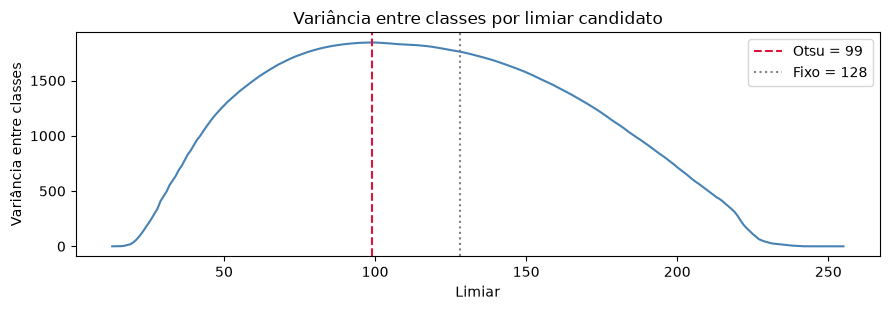

In [8]:
# --- Item (b): método de Otsu ---

def limiar_otsu(imagem, maxval=255):
    """
    Calcula o limiar ótimo pelo método de Otsu.

    Trabalha sobre o histograma normalizado, usando somas acumuladas para
    avaliar todos os limiares candidatos de uma vez.
    """
    hist = np.bincount(imagem.ravel(), minlength=maxval + 1).astype(np.float64)
    prob = hist / hist.sum()

    niveis = np.arange(maxval + 1)
    omega = np.cumsum(prob)                 # proporção da classe 0
    mu = np.cumsum(prob * niveis)           # média acumulada
    mu_total = mu[-1]

    # Variância entre classes; ignora divisões por zero nas extremidades
    with np.errstate(invalid="ignore", divide="ignore"):
        var_entre = (mu_total * omega - mu) ** 2 / (omega * (1 - omega))

    return int(np.nanargmax(var_entre)), var_entre


otsu, curva_var = limiar_otsu(original, maxval)

candidatos = {
    "Ponto médio (128)": LIMIAR_FIXO,
    "Média":             int(round(original.mean())),
    "Mediana":           int(np.median(original)),
    "Otsu":              otsu,
}

print(f"{'Critério':<22}{'Limiar':>8}{'% em 0':>10}{'% em 1':>10}")
print("-" * 50)
for nome, t in candidatos.items():
    b = binarizar(original, t)
    p1 = b.mean() * 100
    print(f"{nome:<22}{t:>8}{100 - p1:>9.2f}%{p1:>9.2f}%")

# Curva da variância entre classes
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(curva_var, color="steelblue")
ax.axvline(otsu, color="crimson", linestyle="--", label=f"Otsu = {otsu}")
ax.axvline(LIMIAR_FIXO, color="gray", linestyle=":", label=f"Fixo = {LIMIAR_FIXO}")
ax.set_title("Variância entre classes por limiar candidato")
ax.set_xlabel("Limiar")
ax.set_ylabel("Variância entre classes")
ax.legend()
plt.tight_layout()
plt.show()

  limiar   % preto (0)   % branco (1)
--------------------------------------
      32         6.52%         93.48%
      64        21.92%         78.08%
      96        31.45%         68.55%
      99        32.17%         67.83%
     128        60.14%         39.86%
     160        79.49%         20.51%
     192        91.07%          8.93%
     224        98.93%          1.07%


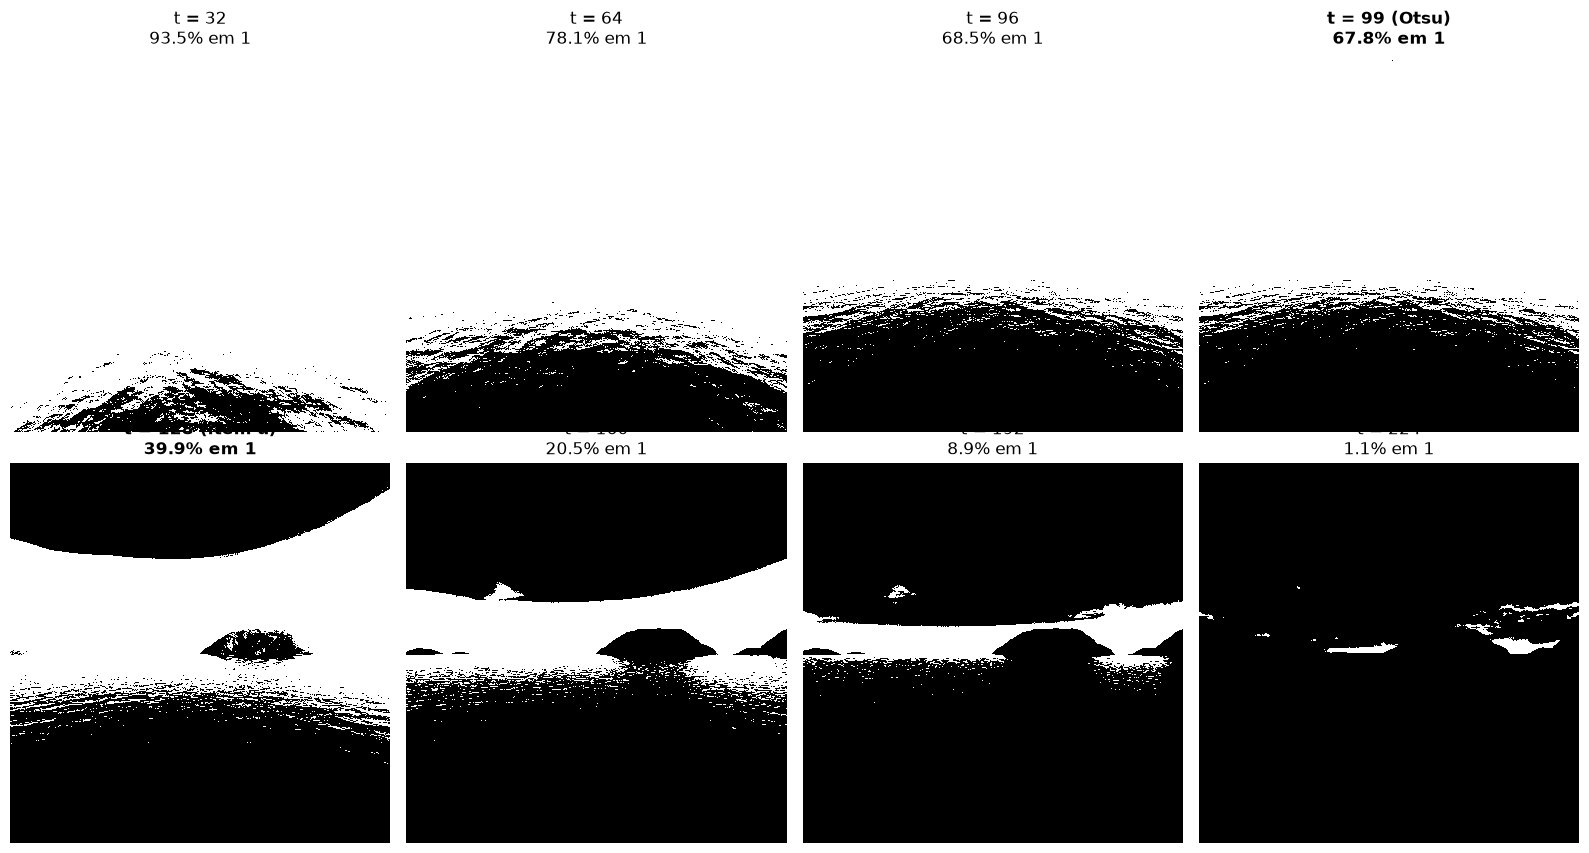


Limiares baixos preservam detalhe nas sombras e saturam as altas luzes;
limiares altos fazem o inverso. O extremo de cada lado converge para uma
imagem uniforme, sem informação alguma.


In [9]:
# --- Item (b): varredura visual de limiares ---

limiares_teste = [32, 64, 96, otsu, 128, 160, 192, 224]
fig, eixos = plt.subplots(2, 4, figsize=(16, 8.5))

print(f"{'limiar':>8}{'% preto (0)':>14}{'% branco (1)':>15}")
print("-" * 38)

for ax, t in zip(eixos.ravel(), sorted(limiares_teste)):
    b = binarizar(original, t)
    p1 = b.mean() * 100

    ax.imshow(b, cmap="gray", vmin=0, vmax=1, interpolation="nearest")

    if t == otsu:
        rotulo, negrito = f"t = {t} (Otsu)", "bold"
    elif t == LIMIAR_FIXO:
        rotulo, negrito = f"t = {t} (item a)", "bold"
    else:
        rotulo, negrito = f"t = {t}", "normal"

    ax.set_title(f"{rotulo}\n{p1:.1f}% em 1", fontweight=negrito)
    ax.axis("off")

    print(f"{t:>8}{100 - p1:>13.2f}%{p1:>14.2f}%")

plt.tight_layout()
plt.show()

print()
print("Limiares baixos preservam detalhe nas sombras e saturam as altas luzes;")
print("limiares altos fazem o inverso. O extremo de cada lado converge para uma")
print("imagem uniforme, sem informação alguma.")

Limiar escolhido: 99 (Otsu)
Arquivo gravado : b_binarizada_limiar99.pbm
Round-trip      : OK
Maior linha     : 70 caracteres


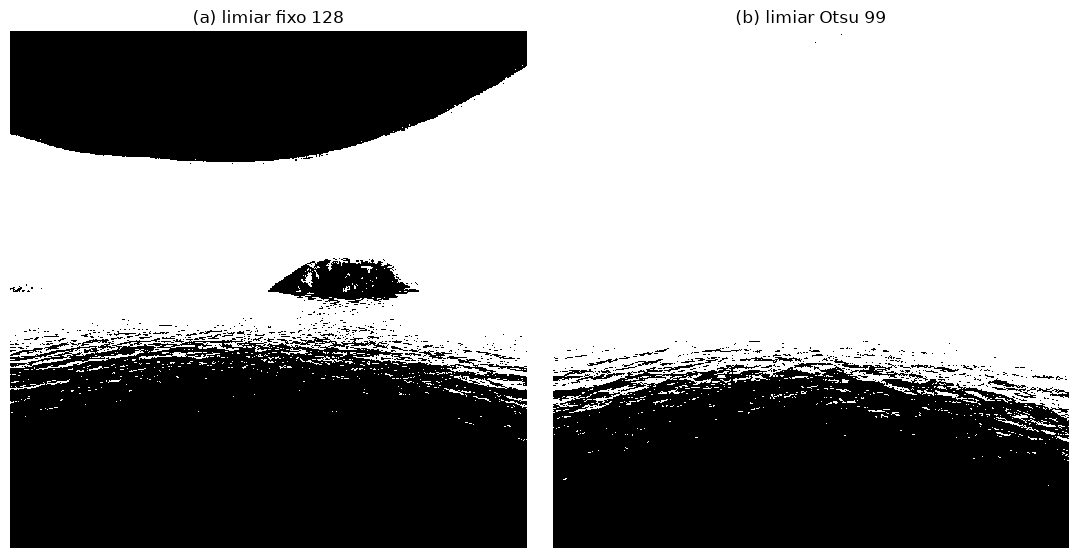

Píxeis classificados de forma diferente entre (a) e (b): 179,012 (27.97%)


In [10]:
# --- Item (b): gravação com o limiar escolhido ---

LIMIAR_ESCOLHIDO = otsu      # ajustável: troque por qualquer valor de 0 a 255

item_b = binarizar(original, LIMIAR_ESCOLHIDO)
ARQUIVO_B = SAIDA / f"b_binarizada_limiar{LIMIAR_ESCOLHIDO}.pbm"

escrever_pbm_p1(
    ARQUIVO_B, item_b,
    comentario=f"item (b) - limiar ajustavel = {LIMIAR_ESCOLHIDO} "
               f"(determinado pelo metodo de Otsu) - origem {ARQUIVO_ENTRADA.name}"
)

assert np.array_equal(ler_pbm_p1(ARQUIVO_B), item_b)

print(f"Limiar escolhido: {LIMIAR_ESCOLHIDO} (Otsu)")
print(f"Arquivo gravado : {ARQUIVO_B.name}")
print(f"Round-trip      : OK")
print(f"Maior linha     : {verificar_limite_colunas(ARQUIVO_B)} caracteres")

fig, eixos = plt.subplots(1, 2, figsize=(11, 5.5))
exibir_pbm(eixos[0], item_a, f"(a) limiar fixo {LIMIAR_FIXO}")
exibir_pbm(eixos[1], item_b, f"(b) limiar Otsu {LIMIAR_ESCOLHIDO}")
plt.tight_layout()
plt.show()

diferentes = int((item_a != item_b).sum())
print(f"Píxeis classificados de forma diferente entre (a) e (b): "
      f"{diferentes:,} ({diferentes / item_a.size * 100:.2f}%)")

---

## Item (c) — Negativo da imagem do item (a)

O negativo troca preto por branco e vice-versa. Em uma imagem binária, isso é
simplesmente a **inversão de cada bit**:

    negativo = 1 - valor

Três formas equivalentes de escrever a mesma operação:

| Forma | Expressão |
|-------|-----------|
| Aritmética | `1 - imagem` |
| XOR bit a bit | `imagem ^ 1` |
| Lógica | `(~imagem.astype(bool)).astype(int)` |

Uso a forma aritmética por ser a que mais se aproxima da definição geral do
negativo, que para uma imagem de profundidade arbitrária é `maxval - valor`. No
PBM o `maxval` é implicitamente 1, e a fórmula geral se reduz a `1 - valor`.

### Propriedade verificável

O negativo é uma **involução**: aplicá-lo duas vezes devolve a imagem original.

    1 - (1 - v) = v

Ao contrário da binarização e da quantização, o negativo **não perde
informação** — é uma operação perfeitamente reversível. A célula de validação
confirma isso numericamente.

In [11]:
# --- Item (c): negativo ---

def negativo(binaria):
    """Inverte uma imagem binária: 0 vira 1, 1 vira 0."""
    return 1 - binaria


item_c = negativo(item_a)

# As três formas devem coincidir
assert np.array_equal(item_c, item_a ^ 1)
assert np.array_equal(item_c, (~item_a.astype(bool)).astype(np.int32))
print("As três formulações do negativo produzem resultado idêntico.")

# Involução: aplicar duas vezes devolve a original
assert np.array_equal(negativo(negativo(item_a)), item_a)
print("Duplo negativo devolve a imagem original — operação reversível.\n")

print(f"{'':<14}{'zeros':>12}{'uns':>12}")
print("-" * 38)
print(f"{'item (a)':<14}{item_a.size - item_a.sum():>12,}{item_a.sum():>12,}")
print(f"{'item (c)':<14}{item_c.size - item_c.sum():>12,}{item_c.sum():>12,}")
print()
print("As contagens estão trocadas entre si, como esperado do negativo.")

As três formulações do negativo produzem resultado idêntico.
Duplo negativo devolve a imagem original — operação reversível.

                     zeros         uns
--------------------------------------
item (a)           384,870     255,130
item (c)           255,130     384,870

As contagens estão trocadas entre si, como esperado do negativo.


In [12]:
# --- Item (c): gravação e validação ---

ARQUIVO_C = SAIDA / "c_negativo_de_a.pbm"

escrever_pbm_p1(
    ARQUIVO_C, item_c,
    comentario=f"item (c) - negativo da imagem do item (a), "
               f"binarizada com limiar {LIMIAR_FIXO} - formato P1 mantido"
)

lida_c = ler_pbm_p1(ARQUIVO_C)
assert np.array_equal(lida_c, item_c)
assert np.array_equal(negativo(lida_c), item_a), "Negativo do arquivo != item (a)"

print(f"Arquivo gravado : {ARQUIVO_C.name}")
print(f"Round-trip      : OK")
print(f"Reversibilidade : OK (negativo do arquivo reproduz o item 'a')")
print(f"Maior linha     : {verificar_limite_colunas(ARQUIVO_C)} caracteres")
print(f"Tamanho         : {ARQUIVO_C.stat().st_size / 1024**2:.2f} MB")
print()
print("Primeiras linhas do arquivo:")
print("-" * 50)
with open(ARQUIVO_C) as f:
    for _ in range(6):
        print(f.readline().rstrip())

Arquivo gravado : c_negativo_de_a.pbm
Round-trip      : OK
Reversibilidade : OK (negativo do arquivo reproduz o item 'a')
Maior linha     : 70 caracteres
Tamanho         : 1.22 MB

Primeiras linhas do arquivo:
--------------------------------------------------
P1
# item (c) - negativo da imagem do item (a), binarizada com limiar 128
# - formato P1 mantido
800 800
1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1


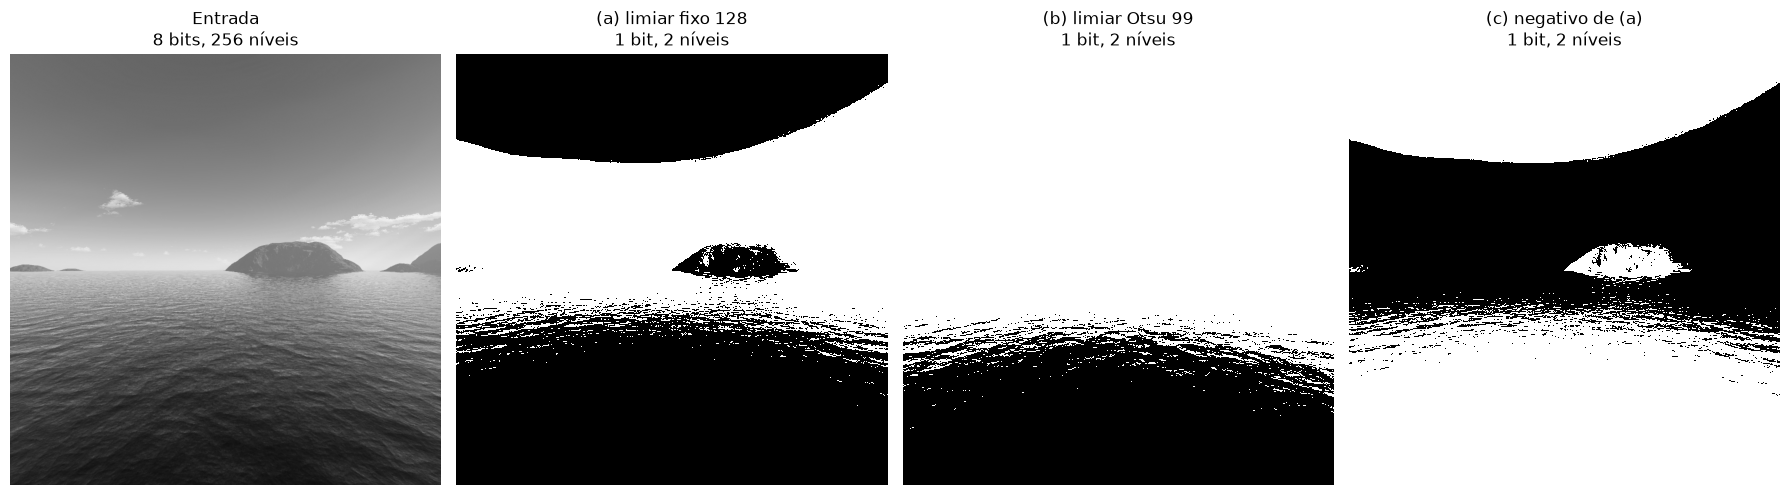

Arquivo                                      Tamanho
------------------------------------------------------
Entrada.pgm                                   2.86 MB
a_binarizada_limiar128.pbm                    1.22 MB
b_binarizada_limiar99.pbm                     1.22 MB
c_negativo_de_a.pbm                           1.22 MB


In [13]:
# --- Painel final: os três itens ---

fig, eixos = plt.subplots(1, 4, figsize=(18, 5))

eixos[0].imshow(original, cmap="gray", vmin=0, vmax=maxval)
eixos[0].set_title("Entrada\n8 bits, 256 níveis")
eixos[0].axis("off")

exibir_pbm(eixos[1], item_a, f"(a) limiar fixo {LIMIAR_FIXO}\n1 bit, 2 níveis")
exibir_pbm(eixos[2], item_b, f"(b) limiar Otsu {LIMIAR_ESCOLHIDO}\n1 bit, 2 níveis")
exibir_pbm(eixos[3], item_c, "(c) negativo de (a)\n1 bit, 2 níveis")

plt.tight_layout()
plt.show()

print(f"{'Arquivo':<40}{'Tamanho':>12}")
print("-" * 54)
for arq in (ARQUIVO_ENTRADA, ARQUIVO_A, ARQUIVO_B, ARQUIVO_C):
    print(f"{arq.name:<40}{arq.stat().st_size / 1024**2:>10.2f} MB")

In [14]:
# --- Verificação final de todos os arquivos gerados ---

gerados = [
    ("a", ARQUIVO_A, item_a),
    ("b", ARQUIVO_B, item_b),
    ("c", ARQUIVO_C, item_c),
]

print(f"{'Item':<6}{'Magic':>7}{'Dimensões':>14}{'Valores':>12}"
      f"{'Round-trip':>13}{'Máx. coluna':>13}")
print("-" * 66)

for rotulo, caminho, esperado in gerados:
    with open(caminho) as f:
        magic = f.readline().strip()

    lida = ler_pbm_p1(caminho)
    valores = sorted(np.unique(lida).tolist())
    ok = "OK" if np.array_equal(lida, esperado) else "FALHOU"
    col = verificar_limite_colunas(caminho)

    print(f"{rotulo:<6}{magic:>7}{f'{lida.shape[1]}x{lida.shape[0]}':>14}"
          f"{str(valores):>12}{ok:>13}{col:>13}")

print()
print("Todos os arquivos: magic number P1, sem campo maxval, apenas valores")
print("0 e 1, e nenhuma linha excedendo 70 caracteres.")

Item    Magic     Dimensões     Valores   Round-trip  Máx. coluna
------------------------------------------------------------------
a          P1       800x800      [0, 1]           OK           69
b          P1       800x800      [0, 1]           OK           70
c          P1       800x800      [0, 1]           OK           70

Todos os arquivos: magic number P1, sem campo maxval, apenas valores
0 e 1, e nenhuma linha excedendo 70 caracteres.


---

## Conclusões

### Arquivos gerados

| Item | Arquivo | Operação |
|------|---------|----------|
| (a) | `a_binarizada_limiar128.pbm` | Limiar fixo em 128 |
| (b) | `b_binarizada_limiar<t>.pbm` | Limiar ajustável, determinado por Otsu |
| (c) | `c_negativo_de_a.pbm` | Negativo do item (a) |

Todos em PBM P1 válido, verificados por round-trip, por conformidade de valores
(apenas 0 e 1) e pelo limite de 70 colunas.

### Sobre a escolha do limiar

O limiar 128 é o ponto médio da escala de 8 bits e não considera nada sobre a
imagem. O método de Otsu chega a um valor diferente porque olha para o
histograma real e busca a separação que maximiza a distinção entre as duas
classes resultantes.

A diferença entre os dois não é cosmética: uma fração relevante dos píxeis muda
de classe. Em aplicações reais — OCR, segmentação, inspeção industrial — essa
diferença costuma decidir se o passo seguinte do pipeline funciona ou não. Vale
notar também que Otsu é um limiar **global**: ele funciona bem quando o
histograma é aproximadamente bimodal, e falha em imagens com iluminação
irregular, caso em que se recorre a limiarização adaptativa por região.

### Sobre a perda de informação

A binarização é a redução de profundidade mais agressiva possível: de 8 bits
para 1, de 256 níveis para 2. Toda a gradação tonal é descartada e não há como
recuperá-la — o que sobra é informação de forma e contorno.

O negativo, ao contrário, é reversível: aplicá-lo duas vezes devolve a imagem
original, propriedade confirmada numericamente no item (c). Vale a distinção
entre os dois tipos de operação: a binarização **destrói** informação, o negativo
apenas a **reorganiza**.

### Sobre a convenção de cor

Registro final da divergência apontada no início. O arquivo gerado segue o
enunciado — píxeis acima do limiar recebem `1`. Sob a convenção da apostila
(`1` = branco), o resultado é a binarização visualmente esperada. Sob a
especificação oficial do PBM (`1` = preto), o mesmo arquivo aparece invertido.

Os bits gravados são os mesmos nos dois casos; o que muda é a interpretação do
visualizador. Caso a intenção fosse compatibilidade com o padrão, bastaria
inverter os valores na gravação — o que, na prática, tornaria o arquivo do item
(a) idêntico ao do item (c).